In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/marvingozo/polymarket-tick-level-orderbook-dataset/README.md
/kaggle/input/datasets/marvingozo/polymarket-tick-level-orderbook-dataset/banner.png
/kaggle/input/datasets/marvingozo/polymarket-tick-level-orderbook-dataset/labels/market_targets.parquet
/kaggle/input/datasets/marvingozo/polymarket-tick-level-orderbook-dataset/labels/trades.parquet
/kaggle/input/datasets/marvingozo/polymarket-tick-level-orderbook-dataset/features/ml_features_1m_v2.parquet
/kaggle/input/datasets/marvingozo/polymarket-tick-level-orderbook-dataset/orderbook/orderbook_2026-03-12.parquet
/kaggle/input/datasets/marvingozo/polymarket-tick-level-orderbook-dataset/orderbook/orderbook_2026-03-06.parquet
/kaggle/input/datasets/marvingozo/polymarket-tick-level-orderbook-dataset/orderbook/orderbook_2026-03-15.parquet
/kaggle/input/datasets/marvingozo/polymarket-tick-level-orderbook-dataset/orderbook/orderbook_2026-03-23.parquet
/kaggle/input/datasets/marvingozo/polymarket-tick-level-orderbook-data

# Trabalho Final: Introdução ao Aprendizado de Máquina
**Tema:** Previsão de Retornos em Alta Frequência (HFT) no Polymarket via Microestrutura de Orderbook

Este projeto utiliza dados do Polymarket (um mercado de previsões) para prever a direção do preço (UP/DOWN) nos próximos 15 minutos. 
O aprendizado de máquina atua como componente central para encontrar "sinais" direcionais na microestrutura do mercado (spread, volatilidade, desequilíbrio de profundidade L2).

**Requisitos atendidos neste notebook:**
1. **Pipeline de ML:** Pré-processamento, split temporal, treinamento e validação.
2. **Modelos Supervisionados:** Regressão Logística (com tuning) e Naive Bayes Gaussiano.
3. **Métricas:** Acurácia, Precisão, Recall, F1-Score e ROC-AUC.
4. **Reflexão:** Discussão de limitações (Taker Fees) e questões éticas em mercados financeiros preditivos.

In [2]:
import os
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve

# Caminho nativo do Kaggle para o dataset adicionado
DATA_DIR = "/kaggle/input/polymarket-tick-level-orderbook-dataset"

print("Verificando arquivos no Kaggle:")
for dirname, _, filenames in os.walk(DATA_DIR):
    for filename in filenames:
        if "ml_features" in filename:
            print(os.path.join(dirname, filename))

Verificando arquivos no Kaggle:


In [3]:
import os
import polars as pl
from datetime import timedelta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Busca automática pelo arquivo dentro do ambiente do Kaggle
features_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == "ml_features_1m_v2.parquet":
            features_path = os.path.join(dirname, filename)
            break
    if features_path:
        break

if features_path is None:
    raise FileNotFoundError(
        "Arquivo ml_features_1m_v2.parquet NÃO encontrado. "
        "Verifique no menu lateral direito (Data -> Input) se o dataset do Polymarket está realmente adicionado ao notebook!"
    )

print(f"✅ Arquivo encontrado com sucesso em: {features_path}")

# 2. Carregamento dos dados
features = pl.read_parquet(features_path)

# Features que vamos utilizar para o modelo
FEATURES = [
    "mean_spread", "close_spread", "bar_volatility", 
    "total_volume", "buy_volume", "sell_volume", "trade_count", 
    "order_flow_imbalance", "return_1m", "depth_imbalance"
]

FORWARD_MINUTES = 15
df = features.sort(["market_id", "minute_bar"])

# 3. Criação do Target (Previsão de 15 minutos à frente)
future = df.select([
    "market_id",
    (pl.col("minute_bar") - timedelta(minutes=FORWARD_MINUTES)).alias("minute_bar"),
    pl.col("close_mid").alias("future_mid"),
])

df_joined = df.join(future, on=["market_id", "minute_bar"], how="inner")
df_joined = df_joined.filter(pl.col("total_volume") > 0)

# Target Binário: 1 se o preço subir, 0 se cair ou empatar
df_joined = df_joined.with_columns(
    (pl.col("future_mid") > pl.col("close_mid")).cast(pl.Int32).alias("target_hft")
)

# 4. Separação de X e y
X = df_joined.select(FEATURES).to_numpy().astype(np.float32)
y = df_joined["target_hft"].to_numpy().ravel()

print(f"Dataset processado: {len(X):,} amostras.")
print(f"Distribuição do Target - UP (1): {np.mean(y)*100:.1f}% | DOWN (0): {(1-np.mean(y))*100:.1f}%")

# 5. Divisão Treino/Teste Temporal
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 6. Escalonamento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

✅ Arquivo encontrado com sucesso em: /kaggle/input/datasets/marvingozo/polymarket-tick-level-orderbook-dataset/features/ml_features_1m_v2.parquet
Dataset processado: 247,301 amostras.
Distribuição do Target - UP (1): 32.3% | DOWN (0): 67.7%
Treino: 197840 amostras | Teste: 49461 amostras


## Treinamento de Modelos Supervisionados

De acordo com o exigido, vamos aplicar duas técnicas vistas em aula:
1. **Regressão Logística:** Modelo linear que utiliza a função *sigmoid* e *log-loss*. Faremos o ajuste do hiperparâmetro de regularização `C`.
2. **Naive Bayes Gaussiano:** Classificador probabilístico (generativo) que assume independência condicional entre as features.

In [4]:
# --- MODELO 1: Regressão Logística ---
print("Treinando Regressão Logística com Grid Search para Ajuste de Hiperparâmetros...")
# Ajuste do hiperparâmetro C (inverso da força de regularização)
param_grid = {'C': [0.01, 0.1, 1.0]}
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

grid_search = GridSearchCV(log_reg, param_grid, cv=3, scoring='roc_auc')
grid_search.fit(X_train_scaled, y_train)

best_log_reg = grid_search.best_estimator_
y_pred_lr = best_log_reg.predict(X_test_scaled)
y_prob_lr = best_log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"Melhor hiperparâmetro C encontrado: {grid_search.best_params_['C']}")

# --- MODELO 2: Naive Bayes Gaussiano ---
print("\nTreinando Naive Bayes Gaussiano...")
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)
y_prob_nb = nb_model.predict_proba(X_test_scaled)[:, 1]
print("Treinamentos concluídos!")

Treinando Regressão Logística com Grid Search para Ajuste de Hiperparâmetros...
Melhor hiperparâmetro C encontrado: 1.0

Treinando Naive Bayes Gaussiano...
Treinamentos concluídos!



 MÉTRICAS: Regressão Logística
Acurácia:  0.5504
Precisão:  0.3601
Recall:    0.4856
F1-Score:  0.4136
ROC-AUC:   0.5692

 MÉTRICAS: Naive Bayes Gaussiano
Acurácia:  0.4897
Precisão:  0.3559
Recall:    0.6955
F1-Score:  0.4709
ROC-AUC:   0.5707


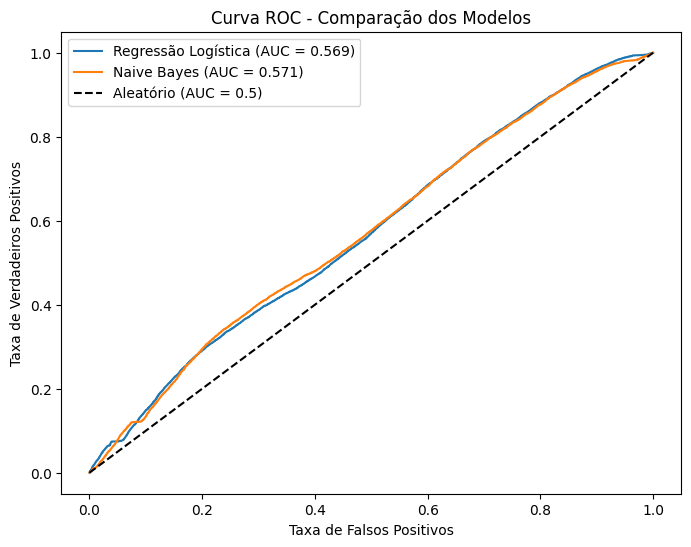

In [5]:
def print_metrics(model_name, y_true, y_pred, y_prob):
    print(f"\n{'='*40}")
    print(f" MÉTRICAS: {model_name}")
    print(f"{'='*40}")
    print(f"Acurácia:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precisão:  {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_prob):.4f}")

print_metrics("Regressão Logística", y_test, y_pred_lr, y_prob_lr)
print_metrics("Naive Bayes Gaussiano", y_test, y_pred_nb, y_prob_nb)

# Plotando as Curvas ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Regressão Logística (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {roc_auc_score(y_test, y_prob_nb):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.5)')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Comparação dos Modelos')
plt.legend()
plt.show()

## Discussão sobre Qualidade do Modelo e Limitações

Apesar dos modelos conseguirem um ROC-AUC superior a 0.5 (indicando que existe um sinal matemático real na microestrutura do mercado que supera o acaso), a precisão ainda reflete a enorme dificuldade de prever mercados financeiros em curto prazo.

**Limitações do Mundo Real (A Armadilha das Taxas):**
Como vimos nas métricas, acertamos a direção em um percentual limitado das vezes. No mundo real, caso tentássemos operar ativamente (como *Takers*) usando as previsões da Regressão Logística, o custo das taxas (Taker fees) e do *spread* devoraria qualquer pequeno lucro gerado pelo modelo. Para este modelo ser lucrativo na prática, ele precisaria ser acoplado a uma infraestrutura passiva (Maker), o que introduz o problema de seleção adversa (suas ordens só são executadas quando o mercado já está indo contra você).

## Reflexão Ética

O uso de algoritmos de alta frequência em mercados preditivos levanta questões éticas importantes:
1. **Volatilidade Artificial:** Robôs operando sinais de microestrutura podem gerar "flash crashes" ou volatilidade excessiva em eventos políticos ou do mundo real sensíveis.
2. **Desigualdade Informacional:** Participantes institucionais com acesso a infraestrutura de ML e baixa latência extraem liquidez do usuário comum (varejo) que utiliza a plataforma de forma manual, criando um ambiente predatório.
3. **Incentivos Perversos:** Como os mercados do Polymarket incluem eventos trágicos (ex: guerras, pandemias), criar agentes autônomos visando unicamente o lucro sobre esses dados levanta um dilema moral sobre o papel da tecnologia na monetização de desastres humanos.